## 讀取資料

In [272]:
from pathlib import Path
import sys
from typing import Optional, Tuple
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

PANEL_PATH = PROJECT_ROOT / "data" / "processed" / "etf_daily_panel.csv"

panel = pd.read_csv(
    PANEL_PATH,
    dtype={"symbol": str},
)

panel["date"] = pd.to_datetime(panel["date"])
panel["symbol"] = panel["symbol"].astype(str)

panel = panel.sort_values(["symbol", "date"]).reset_index(drop=True)

print("Shape:", panel.shape)
print("Date range:", panel["date"].min(), "to", panel["date"].max())
print("Symbols:", sorted(panel["symbol"].unique()))

panel.head()

Shape: (5609, 19)
Date range: 2024-01-02 00:00:00 to 2026-05-18 00:00:00
Symbols: ['0050', '0052', '0056', '006208', '00713', '00878', '00919', '00929', '00939', '00940']


,date,symbol,open,high,low,close,adj_close,volume,nav,prev_nav,nav_change,nav_change_pct,market_price,premium_discount,close_to_nav,market_price_to_nav,close_ret,nav_ret,price_nav_ret_spread
0,2024-01-02,0050,33.900002,33.987499,33.662498,33.724998,31.668650,23688304,135.45,136.20,-0.75,-0.0055,134.90,-0.0041,-0.751015,-0.004061,NaN,NaN,NaN
1,2024-01-03,0050,33.424999,33.474998,33.075001,33.137501,31.116974,54189900,132.66,135.45,-2.79,-0.0206,132.55,-0.0008,-0.750207,-0.000829,-0.017420,-0.020598,0.003178
2,2024-01-04,0050,33.137501,33.187500,33.075001,33.125000,31.105234,18270372,132.86,132.66,0.20,0.0015,132.50,-0.0027,-0.750677,-0.002710,-0.000377,0.001508,-0.001885
3,2024-01-05,0050,33.137501,33.237499,33.025002,33.037498,31.023071,15998684,132.22,132.86,-0.64,-0.0048,132.15,-0.0005,-0.750132,-0.000529,-0.002642,-0.004817,0.002176
4,2024-01-08,0050,33.250000,33.400002,33.187500,33.187500,31.163923,37578880,133.01,132.22,0.79,0.0060,132.75,-0.0020,-0.750489,-0.001955,0.004540,0.005975,-0.001435


## 設定策略參數

In [273]:
# ============================================================
# Strategy Parameters
# ============================================================

universe = [
    "0056",
    "00713",
    "00878",
    "00919",
    "00929",
]

start_date = "2024-01-01"
end_date = None

price_col = "adj_close"

# Signal parameters
z_window = 20
stress_window = 60

# v2.1 baseline parameters
stress_quantile = 0.80

entry_z_diff_stress = 3.5
entry_z_diff_normal = 5.0
exit_z_diff = 1.0

max_holding_days = 10
stop_loss = -0.01

fee_rate = 0.0008
vol_buffer_multiplier = 0.25

## 整理資料成寬表

In [274]:
# ============================================================
# Build Wide Tables
# ============================================================

df = panel[panel["symbol"].isin(universe)].copy()

df = df[df["date"] >= pd.to_datetime(start_date)].copy()

if end_date is not None:
    df = df[df["date"] <= pd.to_datetime(end_date)].copy()

required_cols = [
    "date",
    "symbol",
    price_col,
    "close",
    "open",
    "premium_discount",
    "volume",
]

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

price = df.pivot(index="date", columns="symbol", values=price_col)
open_price = df.pivot(index="date", columns="symbol", values="open")
close_price = df.pivot(index="date", columns="symbol", values="close")
premium = df.pivot(index="date", columns="symbol", values="premium_discount")
volume = df.pivot(index="date", columns="symbol", values="volume")

price = price[universe]
open_price = open_price[universe]
close_price = close_price[universe]
premium = premium[universe]
volume = volume[universe]

print("Price shape:", price.shape)
print("Open shape:", open_price.shape)
print("Close shape:", close_price.shape)
print("Premium shape:", premium.shape)
print("Volume shape:", volume.shape)

premium.tail()

Price shape: (571, 5)
Open shape: (571, 5)
Close shape: (571, 5)
Premium shape: (571, 5)
Volume shape: (571, 5)


symbol,0056,00713,00878,00919,00929
date,,,,,
2026-05-12,-0.0004,-0.0080,-0.0025,-0.0031,-0.0034
2026-05-13,-0.0020,-0.0040,-0.0018,-0.0035,-0.0043
2026-05-14,-0.0024,-0.0054,-0.0028,-0.0038,-0.0034
2026-05-15,-0.0018,-0.0034,0.0011,-0.0046,-0.0039
2026-05-18,0.0014,-0.0033,0.0025,-0.0035,-0.0035


## 計算 relative premium 與 z-score

In [275]:
# ============================================================
# Relative Premium and Z-score
# ============================================================

group_median_premium = premium.median(axis=1)

relative_premium = premium.sub(group_median_premium, axis=0)

relative_mean = relative_premium.rolling(z_window).mean()
relative_std = relative_premium.rolling(z_window).std()

relative_z = (relative_premium - relative_mean) / relative_std

relative_z.tail()

symbol,0056,00713,00878,00919,00929
date,,,,,
2026-05-12,-0.506269,-2.552315,-0.233110,-0.301138,-0.006691
2026-05-13,-1.074777,0.543743,0.227036,-0.192088,-0.618324
2026-05-14,-1.224075,-0.494816,-0.318493,-0.419377,0.445460
2026-05-15,-0.831477,0.896385,1.366433,-1.723927,-0.233881
2026-05-18,0.741545,0.896385,1.705322,0.053112,0.428189


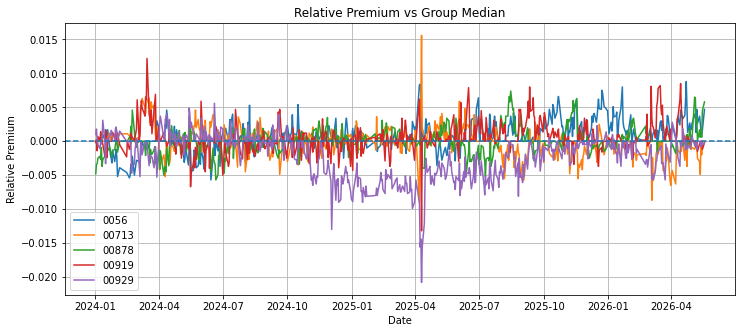

In [276]:
plt.figure(figsize=(12, 5))

for symbol in universe:
    plt.plot(
        relative_premium.index.to_numpy(),
        relative_premium[symbol].to_numpy(),
        label=symbol,
    )

plt.axhline(0, linestyle="--")
plt.title("Relative Premium vs Group Median")
plt.xlabel("Date")
plt.ylabel("Relative Premium")
plt.legend()
plt.grid(True)
plt.show()

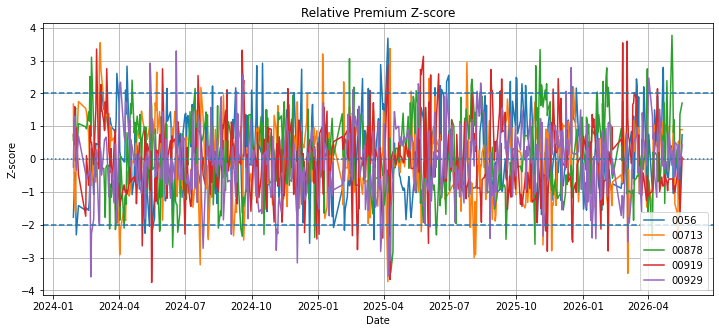

In [277]:
plt.figure(figsize=(12, 5))

for symbol in universe:
    plt.plot(
        relative_z.index.to_numpy(),
        relative_z[symbol].to_numpy(),
        label=symbol,
    )

plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.axhline(0, linestyle=":")
plt.title("Relative Premium Z-score")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.grid(True)
plt.show()

## 建立報酬、stress mode、dynamic min edge

In [278]:
# ============================================================
# Returns, Stress Mode, Dynamic Edge
# ============================================================

returns = price.pct_change()

open_to_close_returns = close_price / open_price - 1

market_abs_ret = returns[universe].abs().mean(axis=1)

stress_threshold = market_abs_ret.rolling(stress_window).quantile(
    stress_quantile
)

stress_mode = market_abs_ret > stress_threshold

pair_vol_proxy = returns[universe].std(axis=1).rolling(20).mean()

dynamic_min_edge = (
    2 * fee_rate
    + vol_buffer_multiplier * pair_vol_proxy
)

stress_info = pd.DataFrame({
    "market_abs_ret": market_abs_ret,
    "stress_threshold": stress_threshold,
    "stress_mode": stress_mode,
    "dynamic_min_edge": dynamic_min_edge,
})

stress_info.tail()

,market_abs_ret,stress_threshold,stress_mode,dynamic_min_edge
date,,,,
2026-05-12,0.003760,0.016993,False,0.003211
2026-05-13,0.008609,0.016993,False,0.003246
2026-05-14,0.008679,0.016993,False,0.003287
2026-05-15,0.008662,0.016993,False,0.003293
2026-05-18,0.004119,0.016993,False,0.003282


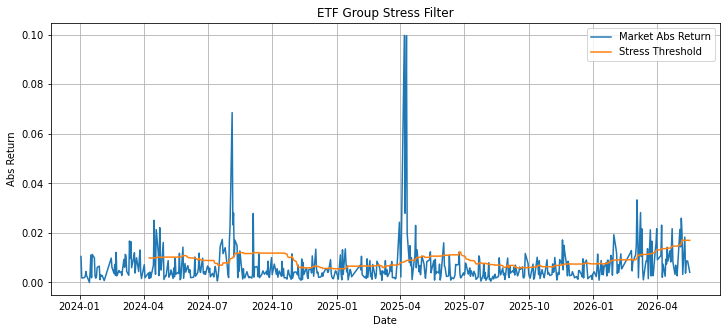

In [279]:
plt.figure(figsize=(12, 5))

plt.plot(
    stress_info.index.to_numpy(),
    stress_info["market_abs_ret"].to_numpy(),
    label="Market Abs Return",
)

plt.plot(
    stress_info.index.to_numpy(),
    stress_info["stress_threshold"].to_numpy(),
    label="Stress Threshold",
)

plt.title("ETF Group Stress Filter")
plt.xlabel("Date")
plt.ylabel("Abs Return")
plt.legend()
plt.grid(True)
plt.show()

## 產生策略訊號

In [280]:
# ============================================================
# Stateful RV Signal Generator V2.1
# ============================================================

def generate_stateful_rv_signals_v21(
    relative_z: pd.DataFrame,
    relative_premium: pd.DataFrame,
    stress_mode: pd.Series,
    dynamic_min_edge: pd.Series,
    entry_z_diff_stress: float = 3.5,
    entry_z_diff_normal: float = 5.0,
    exit_z_diff: float = 1.0,
    max_holding_days: int = 5,
    stop_loss: float = -0.01,
    returns_for_pnl: Optional[pd.DataFrame] = None,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Stateful high-dividend ETF relative premium strategy v2.1.

    Entry:
    - choose lowest z as long candidate
    - choose highest z as short candidate
    - stress days use lower entry threshold
    - normal days use higher entry threshold
    - premium_diff must exceed dynamic_min_edge

    Exit:
    - z_diff < exit_z_diff
    - holding_days >= max_holding_days
    - trade_pnl <= stop_loss
    """

    signals = pd.DataFrame(
        0.0,
        index=relative_z.index,
        columns=relative_z.columns,
    )

    trade_logs = []

    in_position = False
    long_symbol = None
    short_symbol = None
    entry_date = None
    holding_days = 0
    trade_pnl = 0.0

    entry_z_diff_value = np.nan
    entry_premium_diff_value = np.nan
    entry_regime = None

    for date in relative_z.index:
        z_row = relative_z.loc[date].dropna()
        premium_row = relative_premium.loc[date].dropna()

        valid_symbols = z_row.index.intersection(premium_row.index)

        if len(valid_symbols) < 2:
            continue

        z_row = z_row[valid_symbols]
        premium_row = premium_row[valid_symbols]

        # ====================================================
        # 1. If currently holding a pair, check exit conditions
        # ====================================================
        if in_position:
            current_z_diff = (
                z_row.get(short_symbol, np.nan)
                - z_row.get(long_symbol, np.nan)
            )

            current_premium_diff = (
                premium_row.get(short_symbol, np.nan)
                - premium_row.get(long_symbol, np.nan)
            )

            if returns_for_pnl is not None and date in returns_for_pnl.index:
                if (
                    long_symbol in returns_for_pnl.columns
                    and short_symbol in returns_for_pnl.columns
                ):
                    daily_pnl = (
                        0.5 * returns_for_pnl.loc[date, long_symbol]
                        - 0.5 * returns_for_pnl.loc[date, short_symbol]
                    )

                    if not pd.isna(daily_pnl):
                        trade_pnl += daily_pnl

            exit_reason = None

            if pd.notna(current_z_diff) and current_z_diff < exit_z_diff:
                exit_reason = "mean_reversion"

            elif holding_days >= max_holding_days:
                exit_reason = "max_holding_days"

            elif trade_pnl <= stop_loss:
                exit_reason = "stop_loss"

            if exit_reason is not None:
                trade_logs.append({
                    "entry_date": entry_date,
                    "exit_date": date,
                    "long_symbol": long_symbol,
                    "short_symbol": short_symbol,
                    "holding_days": holding_days,
                    "entry_regime": entry_regime,
                    "entry_z_diff": entry_z_diff_value,
                    "exit_z_diff": current_z_diff,
                    "entry_premium_diff": entry_premium_diff_value,
                    "exit_premium_diff": current_premium_diff,
                    "trade_pnl_before_cost": trade_pnl,
                    "exit_reason": exit_reason,
                })

                in_position = False
                long_symbol = None
                short_symbol = None
                entry_date = None
                holding_days = 0
                trade_pnl = 0.0

                entry_z_diff_value = np.nan
                entry_premium_diff_value = np.nan
                entry_regime = None

                continue

            else:
                signals.loc[date, long_symbol] = 0.5
                signals.loc[date, short_symbol] = -0.5
                holding_days += 1
                continue

        # ====================================================
        # 2. If flat, check entry conditions
        # ====================================================
        long_candidate = z_row.idxmin()
        short_candidate = z_row.idxmax()

        if long_candidate == short_candidate:
            continue

        z_diff = z_row[short_candidate] - z_row[long_candidate]

        premium_diff = (
            premium_row[short_candidate]
            - premium_row[long_candidate]
        )

        min_edge_today = dynamic_min_edge.loc[date]

        if pd.isna(z_diff) or pd.isna(premium_diff) or pd.isna(min_edge_today):
            continue

        is_stress = bool(stress_mode.loc[date])

        if is_stress:
            entry_threshold = entry_z_diff_stress
            regime = "stress"
        else:
            entry_threshold = entry_z_diff_normal
            regime = "normal"

        entry_ok = (
            z_diff > entry_threshold
            and premium_diff > min_edge_today
        )

        if entry_ok:
            in_position = True
            long_symbol = long_candidate
            short_symbol = short_candidate
            entry_date = date
            holding_days = 1
            trade_pnl = 0.0

            entry_z_diff_value = z_diff
            entry_premium_diff_value = premium_diff
            entry_regime = regime

            signals.loc[date, long_symbol] = 0.5
            signals.loc[date, short_symbol] = -0.5

    trade_logs = pd.DataFrame(trade_logs)

    return signals, trade_logs

## 回測函數

In [281]:
# ============================================================
# Backtest Function
# ============================================================

def backtest_signals(
    signals: pd.DataFrame,
    returns: pd.DataFrame,
    fee_rate: float = 0.0008,
    execution_lag: int = 1,
) -> dict:
    """
    Backtest signal matrix.

    signals:
    - date x symbol weights

    execution_lag:
    - 1 means t signal held on t+1
    - 2 means t signal held on t+2
    """

    positions = signals.shift(execution_lag).fillna(0)

    gross_ret = (positions * returns).sum(axis=1)

    turnover = positions.diff().abs().sum(axis=1).fillna(0)

    cost = turnover * fee_rate

    strategy_ret = gross_ret - cost

    equity = (1 + strategy_ret.fillna(0)).cumprod()

    drawdown = equity / equity.cummax() - 1

    metrics = {
        "total_return": equity.iloc[-1] - 1,
        "gross_return_sum": gross_ret.sum(),
        "cost_sum": cost.sum(),
        "net_return_sum": strategy_ret.sum(),
        "max_drawdown": drawdown.min(),
        "trade_days": (positions.abs().sum(axis=1) > 0).sum(),
        "turnover_sum": turnover.sum(),
        "exposure_ratio": (positions.abs().sum(axis=1) > 0).mean(),
    }

    result = {
        "positions": positions,
        "gross_ret": gross_ret,
        "turnover": turnover,
        "cost": cost,
        "strategy_ret": strategy_ret,
        "equity": equity,
        "drawdown": drawdown,
        "metrics": metrics,
    }

    return result

## 跑 v2.1 baseline 策略

In [282]:
# ============================================================
# Run Baseline V2.1 Strategy
# ============================================================

signals_v21, trade_logs_v21 = generate_stateful_rv_signals_v21(
    relative_z=relative_z,
    relative_premium=relative_premium,
    stress_mode=stress_mode,
    dynamic_min_edge=dynamic_min_edge,
    entry_z_diff_stress=entry_z_diff_stress,
    entry_z_diff_normal=entry_z_diff_normal,
    exit_z_diff=exit_z_diff,
    max_holding_days=max_holding_days,
    stop_loss=stop_loss,
    returns_for_pnl=returns,
)

print("Trade logs shape:", trade_logs_v21.shape)

active_days_v21 = (signals_v21.abs().sum(axis=1) > 0).sum()
print("Active days:", active_days_v21)

trade_logs_v21

Trade logs shape: (26, 12)
Active days: 70


,entry_date,exit_date,long_symbol,short_symbol,holding_days,entry_regime,entry_z_diff,exit_z_diff,entry_premium_diff,exit_premium_diff,trade_pnl_before_cost,exit_reason
0,2024-02-23,2024-02-27,00929,00878,2,normal,5.369613,0.638883,0.0082,0.0012,0.005775,mean_reversion
1,2024-03-05,2024-03-12,00929,00713,5,normal,5.074057,0.893665,0.0078,0.0052,0.010028,mean_reversion
2,2024-04-02,2024-04-17,00713,00929,9,normal,5.151710,0.549966,0.0068,0.0020,0.012595,mean_reversion
3,2024-05-16,2024-05-20,00919,00878,2,normal,5.353673,0.933769,0.0090,0.0033,0.002061,mean_reversion
4,2024-05-27,2024-05-29,00878,00713,2,stress,3.645029,0.255626,0.0057,0.0016,-0.000578,mean_reversion
5,2024-06-19,2024-06-25,00878,00929,4,stress,4.666812,-0.364459,0.0087,0.0021,0.006652,mean_reversion
6,2024-07-22,2024-07-23,00713,00929,1,stress,4.277956,-2.780411,0.0054,-0.0038,0.003867,mean_reversion
7,2024-07-26,2024-07-29,00929,00713,1,stress,4.006662,0.588311,0.0061,0.0011,-0.003064,mean_reversion
8,2024-09-18,2024-09-23,00878,00919,3,normal,5.670175,0.691410,0.0068,0.0013,0.002214,mean_reversion
9,2025-02-13,2025-02-14,0056,00878,1,stress,3.871421,0.311316,0.0036,0.0005,0.000634,mean_reversion


## 回測 baseline 三種版本

In [283]:
bt_v21_close = backtest_signals(
    signals=signals_v21,
    returns=returns,
    fee_rate=fee_rate,
    execution_lag=1,
)

bt_v21_open_close = backtest_signals(
    signals=signals_v21,
    returns=open_to_close_returns,
    fee_rate=fee_rate,
    execution_lag=1,
)

bt_v21_delay2 = backtest_signals(
    signals=signals_v21,
    returns=returns,
    fee_rate=fee_rate,
    execution_lag=2,
)

compare_v21 = pd.DataFrame({
    "v21_close_to_close": bt_v21_close["metrics"],
    "v21_open_to_close": bt_v21_open_close["metrics"],
    "v21_delay2": bt_v21_delay2["metrics"],
})

compare_v21

,v21_close_to_close,v21_open_to_close,v21_delay2
total_return,0.067366,0.050307,0.010914
gross_return_sum,0.107720,0.091305,0.052755
cost_sum,0.041600,0.041600,0.041600
net_return_sum,0.066120,0.049705,0.011155
max_drawdown,-0.030784,-0.021223,-0.025420
trade_days,70.000000,70.000000,70.000000
turnover_sum,52.000000,52.000000,52.000000
exposure_ratio,0.122592,0.122592,0.122592


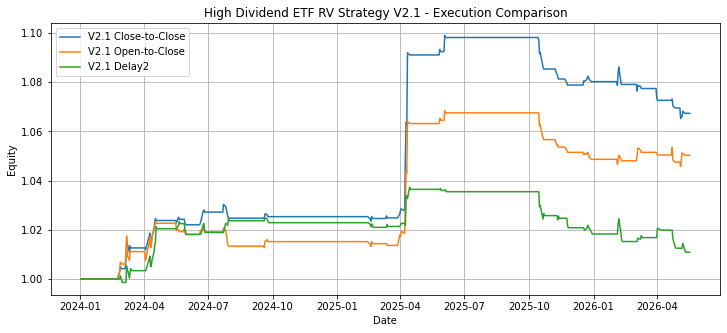

In [284]:
plt.figure(figsize=(12, 5))

plt.plot(
    bt_v21_close["equity"].index.to_numpy(),
    bt_v21_close["equity"].to_numpy(),
    label="V2.1 Close-to-Close",
)

plt.plot(
    bt_v21_open_close["equity"].index.to_numpy(),
    bt_v21_open_close["equity"].to_numpy(),
    label="V2.1 Open-to-Close",
)

plt.plot(
    bt_v21_delay2["equity"].index.to_numpy(),
    bt_v21_delay2["equity"].to_numpy(),
    label="V2.1 Delay2",
)

plt.title("High Dividend ETF RV Strategy V2.1 - Execution Comparison")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()
plt.grid(True)
plt.show()

## 檢查 baseline 交易紀錄

In [285]:
if not trade_logs_v21.empty:
    display(trade_logs_v21[
        [
            "entry_date",
            "exit_date",
            "long_symbol",
            "short_symbol",
            "holding_days",
            "entry_regime",
            "entry_z_diff",
            "exit_z_diff",
            "entry_premium_diff",
            "exit_premium_diff",
            "trade_pnl_before_cost",
            "exit_reason",
        ]
    ])

    print("Exit reason counts:")
    print(trade_logs_v21["exit_reason"].value_counts())

    print("\nEntry regime counts:")
    print(trade_logs_v21["entry_regime"].value_counts())

else:
    print("No trades generated.")

,entry_date,exit_date,long_symbol,short_symbol,holding_days,entry_regime,entry_z_diff,exit_z_diff,entry_premium_diff,exit_premium_diff,trade_pnl_before_cost,exit_reason
0,2024-02-23,2024-02-27,00929,00878,2,normal,5.369613,0.638883,0.0082,0.0012,0.005775,mean_reversion
1,2024-03-05,2024-03-12,00929,00713,5,normal,5.074057,0.893665,0.0078,0.0052,0.010028,mean_reversion
2,2024-04-02,2024-04-17,00713,00929,9,normal,5.151710,0.549966,0.0068,0.0020,0.012595,mean_reversion
3,2024-05-16,2024-05-20,00919,00878,2,normal,5.353673,0.933769,0.0090,0.0033,0.002061,mean_reversion
4,2024-05-27,2024-05-29,00878,00713,2,stress,3.645029,0.255626,0.0057,0.0016,-0.000578,mean_reversion
5,2024-06-19,2024-06-25,00878,00929,4,stress,4.666812,-0.364459,0.0087,0.0021,0.006652,mean_reversion
6,2024-07-22,2024-07-23,00713,00929,1,stress,4.277956,-2.780411,0.0054,-0.0038,0.003867,mean_reversion
7,2024-07-26,2024-07-29,00929,00713,1,stress,4.006662,0.588311,0.0061,0.0011,-0.003064,mean_reversion
8,2024-09-18,2024-09-23,00878,00919,3,normal,5.670175,0.691410,0.0068,0.0013,0.002214,mean_reversion
9,2025-02-13,2025-02-14,0056,00878,1,stress,3.871421,0.311316,0.0036,0.0005,0.000634,mean_reversion


Exit reason counts:
exit_reason
mean_reversion    25
stop_loss          1
Name: count, dtype: int64

Entry regime counts:
entry_regime
stress    20
normal     6
Name: count, dtype: int64


## 參數最佳化

In [286]:
# ============================================================
# Parameter Optimization
# Test only:
# 1. stress_quantile
# 2. entry_z_diff
# 3. exit_z_diff
# ============================================================

stress_quantile_list = [0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
entry_z_diff_list = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
exit_z_diff_list = [0, 0.5, 1.0, 1.5, 2.0]

# Fixed parameters
fixed_entry_z_diff_normal = 5.0
fixed_max_holding_days = 10
fixed_stop_loss = -0.01
fixed_vol_buffer_multiplier = 0.25

optimization_results = []

total_runs = (
    len(stress_quantile_list)
    * len(entry_z_diff_list)
    * len(exit_z_diff_list)
)

print("Total parameter combinations:", total_runs)

run_id = 0

for stress_quantile_i, entry_z_diff_i, exit_z_diff_i in product(
    stress_quantile_list,
    entry_z_diff_list,
    exit_z_diff_list,
):

    run_id += 1

    if exit_z_diff_i >= entry_z_diff_i:
        continue

    # Recalculate stress mode
    stress_threshold_i = market_abs_ret.rolling(stress_window).quantile(
        stress_quantile_i
    )

    stress_mode_i = market_abs_ret > stress_threshold_i

    # Recalculate dynamic min edge
    dynamic_min_edge_i = (
        2 * fee_rate
        + fixed_vol_buffer_multiplier * pair_vol_proxy
    )

    # Generate signals
    signals_i, trade_logs_i = generate_stateful_rv_signals_v21(
        relative_z=relative_z,
        relative_premium=relative_premium,
        stress_mode=stress_mode_i,
        dynamic_min_edge=dynamic_min_edge_i,
        entry_z_diff_stress=entry_z_diff_i,
        entry_z_diff_normal=fixed_entry_z_diff_normal,
        exit_z_diff=exit_z_diff_i,
        max_holding_days=fixed_max_holding_days,
        stop_loss=fixed_stop_loss,
        returns_for_pnl=returns,
    )

    active_days_i = (signals_i.abs().sum(axis=1) > 0).sum()
    trade_count_i = len(trade_logs_i)

    # Close-to-close
    bt_close_i = backtest_signals(
        signals=signals_i,
        returns=returns,
        fee_rate=fee_rate,
        execution_lag=1,
    )

    # Open-to-close
    bt_oc_i = backtest_signals(
        signals=signals_i,
        returns=open_to_close_returns,
        fee_rate=fee_rate,
        execution_lag=1,
    )

    # Delay2
    bt_delay2_i = backtest_signals(
        signals=signals_i,
        returns=returns,
        fee_rate=fee_rate,
        execution_lag=2,
    )

    close_metrics = bt_close_i["metrics"]
    oc_metrics = bt_oc_i["metrics"]
    delay2_metrics = bt_delay2_i["metrics"]

    row = {
        "run_id": run_id,

        # Parameters
        "stress_quantile": stress_quantile_i,
        "entry_z_diff": entry_z_diff_i,
        "exit_z_diff": exit_z_diff_i,

        # Fixed parameters
        "entry_z_diff_normal": fixed_entry_z_diff_normal,
        "max_holding_days": fixed_max_holding_days,
        "stop_loss": fixed_stop_loss,
        "vol_buffer_multiplier": fixed_vol_buffer_multiplier,

        # Trade info
        "trade_count": trade_count_i,
        "active_days": active_days_i,

        # Close-to-close metrics
        "close_total_return": close_metrics["total_return"],
        "close_gross_return_sum": close_metrics["gross_return_sum"],
        "close_cost_sum": close_metrics["cost_sum"],
        "close_net_return_sum": close_metrics["net_return_sum"],
        "close_max_drawdown": close_metrics["max_drawdown"],
        "close_turnover_sum": close_metrics["turnover_sum"],
        "close_exposure_ratio": close_metrics["exposure_ratio"],

        # Open-to-close metrics
        "oc_total_return": oc_metrics["total_return"],
        "oc_gross_return_sum": oc_metrics["gross_return_sum"],
        "oc_cost_sum": oc_metrics["cost_sum"],
        "oc_net_return_sum": oc_metrics["net_return_sum"],
        "oc_max_drawdown": oc_metrics["max_drawdown"],
        "oc_turnover_sum": oc_metrics["turnover_sum"],
        "oc_exposure_ratio": oc_metrics["exposure_ratio"],

        # Delay2 metrics
        "delay2_total_return": delay2_metrics["total_return"],
        "delay2_gross_return_sum": delay2_metrics["gross_return_sum"],
        "delay2_cost_sum": delay2_metrics["cost_sum"],
        "delay2_net_return_sum": delay2_metrics["net_return_sum"],
        "delay2_max_drawdown": delay2_metrics["max_drawdown"],
        "delay2_turnover_sum": delay2_metrics["turnover_sum"],
        "delay2_exposure_ratio": delay2_metrics["exposure_ratio"],
    }

    optimization_results.append(row)

opt_df = pd.DataFrame(optimization_results)

print("Optimization result shape:", opt_df.shape)

opt_df.head()

Total parameter combinations: 210
Optimization result shape: (204, 31)


,run_id,stress_quantile,entry_z_diff,exit_z_diff,entry_z_diff_normal,max_holding_days,stop_loss,vol_buffer_multiplier,trade_count,active_days,...,oc_max_drawdown,oc_turnover_sum,oc_exposure_ratio,delay2_total_return,delay2_gross_return_sum,delay2_cost_sum,delay2_net_return_sum,delay2_max_drawdown,delay2_turnover_sum,delay2_exposure_ratio
0,1,0.4,2.0,0.0,5.0,10,-0.01,0.25,64,286,...,-0.050948,127.0,0.500876,-0.060092,0.040687,0.1016,-0.060913,-0.089498,127.0,0.499124
1,2,0.4,2.0,0.5,5.0,10,-0.01,0.25,76,247,...,-0.038677,153.0,0.430823,-0.077929,0.041465,0.1216,-0.080135,-0.091231,152.0,0.429072
2,3,0.4,2.0,1.0,5.0,10,-0.01,0.25,82,218,...,-0.034802,165.0,0.380035,-0.091168,0.036443,0.1312,-0.094757,-0.110087,164.0,0.378284
3,4,0.4,2.0,1.5,5.0,10,-0.01,0.25,91,195,...,-0.054993,183.0,0.339755,-0.109996,0.029812,0.1456,-0.115788,-0.127551,182.0,0.338004
4,6,0.4,2.5,0.0,5.0,10,-0.01,0.25,61,272,...,-0.042604,121.0,0.476357,-0.069484,0.025799,0.0968,-0.071001,-0.098596,121.0,0.474606


In [287]:
# ============================================================
# Evaluation Metrics
# ============================================================

opt_df = opt_df.copy()

opt_df["oc_cost_to_gross"] = (
    opt_df["oc_cost_sum"]
    / opt_df["oc_gross_return_sum"].replace(0, np.nan)
)

opt_df["oc_net_to_gross"] = (
    opt_df["oc_net_return_sum"]
    / opt_df["oc_gross_return_sum"].replace(0, np.nan)
)

opt_df["oc_retention_ratio"] = (
    opt_df["oc_net_return_sum"]
    / opt_df["close_net_return_sum"].replace(0, np.nan)
)

opt_df["delay2_retention_ratio"] = (
    opt_df["delay2_net_return_sum"]
    / opt_df["close_net_return_sum"].replace(0, np.nan)
)

opt_df["oc_return_over_dd"] = (
    opt_df["oc_net_return_sum"]
    / opt_df["oc_max_drawdown"].abs().replace(0, np.nan)
)

opt_df["score"] = (
    opt_df["oc_net_return_sum"]
    + 0.5 * opt_df["delay2_net_return_sum"]
    - 0.5 * opt_df["oc_max_drawdown"].abs()
)

filtered_opt = opt_df[
    (opt_df["trade_count"] >= 3)
    & (opt_df["active_days"] >= 10)
    & (opt_df["oc_net_return_sum"] > 0)
    & (opt_df["delay2_net_return_sum"] > 0)
].copy()

print("Filtered shape:", filtered_opt.shape)

filtered_opt.sort_values("score", ascending=False).head(20)

Filtered shape: (125, 37)


,run_id,stress_quantile,entry_z_diff,exit_z_diff,entry_z_diff_normal,max_holding_days,stop_loss,vol_buffer_multiplier,trade_count,active_days,...,delay2_net_return_sum,delay2_max_drawdown,delay2_turnover_sum,delay2_exposure_ratio,oc_cost_to_gross,oc_net_to_gross,oc_retention_ratio,delay2_retention_ratio,oc_return_over_dd,score
94,98,0.6,4.5,1.0,5.0,10,-0.01,0.25,13,40,...,0.032357,-0.006956,26.0,0.070053,0.210763,0.789237,0.841379,0.349532,7.921877,0.089152
60,63,0.5,4.5,1.0,5.0,10,-0.01,0.25,13,40,...,0.032357,-0.006956,26.0,0.070053,0.210763,0.789237,0.841379,0.349532,7.921877,0.089152
162,168,0.8,4.5,1.0,5.0,10,-0.01,0.25,11,36,...,0.038188,-0.004878,22.0,0.063047,0.190663,0.809337,0.805107,0.411530,7.598515,0.088888
128,133,0.7,4.5,1.0,5.0,10,-0.01,0.25,11,36,...,0.038188,-0.004878,22.0,0.063047,0.190663,0.809337,0.805107,0.411530,7.598515,0.088888
176,183,0.9,2.5,1.0,5.0,10,-0.01,0.25,24,62,...,0.030591,-0.012947,48.0,0.108581,0.329419,0.670581,0.777242,0.304174,7.950334,0.088548
196,203,0.9,4.5,1.0,5.0,10,-0.01,0.25,10,32,...,0.037433,-0.004878,20.0,0.056042,0.178426,0.821574,0.839647,0.426626,7.493058,0.087473
175,182,0.9,2.5,0.5,5.0,10,-0.01,0.25,22,81,...,0.018996,-0.013480,44.0,0.141856,0.298758,0.701242,0.787337,0.181026,6.709247,0.085962
92,96,0.6,4.5,0.0,5.0,10,-0.01,0.25,13,61,...,0.030447,-0.014929,26.0,0.106830,0.205931,0.794069,0.814718,0.309275,4.116648,0.085687
58,61,0.5,4.5,0.0,5.0,10,-0.01,0.25,13,61,...,0.030447,-0.014929,26.0,0.106830,0.205931,0.794069,0.814718,0.309275,4.116648,0.085687
160,166,0.8,4.5,0.0,5.0,10,-0.01,0.25,11,55,...,0.039932,-0.014929,22.0,0.096322,0.189343,0.810657,0.754602,0.399884,3.867620,0.085577


## 查看最佳前 20 名

In [288]:
show_cols = [
    "stress_quantile",
    "entry_z_diff",
    "exit_z_diff",

    "trade_count",
    "active_days",

    "close_net_return_sum",
    "oc_net_return_sum",
    "delay2_net_return_sum",

    "oc_max_drawdown",
    "oc_cost_sum",
    "oc_turnover_sum",
    "oc_exposure_ratio",

    "oc_cost_to_gross",
    "oc_net_to_gross",
    "oc_retention_ratio",
    "delay2_retention_ratio",
    "score",
]

top_results = (
    filtered_opt[show_cols]
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

top_results.head(20)

,stress_quantile,entry_z_diff,exit_z_diff,trade_count,active_days,close_net_return_sum,oc_net_return_sum,delay2_net_return_sum,oc_max_drawdown,oc_cost_sum,oc_turnover_sum,oc_exposure_ratio,oc_cost_to_gross,oc_net_to_gross,oc_retention_ratio,delay2_retention_ratio,score
0,0.6,4.5,1.0,13,40,0.092573,0.077889,0.032357,-0.009832,0.0208,26.0,0.070053,0.210763,0.789237,0.841379,0.349532,0.089152
1,0.5,4.5,1.0,13,40,0.092573,0.077889,0.032357,-0.009832,0.0208,26.0,0.070053,0.210763,0.789237,0.841379,0.349532,0.089152
2,0.8,4.5,1.0,11,36,0.092795,0.074710,0.038188,-0.009832,0.0176,22.0,0.063047,0.190663,0.809337,0.805107,0.411530,0.088888
3,0.7,4.5,1.0,11,36,0.092795,0.074710,0.038188,-0.009832,0.0176,22.0,0.063047,0.190663,0.809337,0.805107,0.411530,0.088888
4,0.9,2.5,1.0,24,62,0.100572,0.078169,0.030591,-0.009832,0.0384,48.0,0.108581,0.329419,0.670581,0.777242,0.304174,0.088548
5,0.9,4.5,1.0,10,32,0.087743,0.073673,0.037433,-0.009832,0.0160,20.0,0.056042,0.178426,0.821574,0.839647,0.426626,0.087473
6,0.9,2.5,0.5,22,81,0.104937,0.082621,0.018996,-0.012314,0.0352,44.0,0.141856,0.298758,0.701242,0.787337,0.181026,0.085962
7,0.6,4.5,0.0,13,61,0.098445,0.080205,0.030447,-0.019483,0.0208,26.0,0.106830,0.205931,0.794069,0.814718,0.309275,0.085687
8,0.5,4.5,0.0,13,61,0.098445,0.080205,0.030447,-0.019483,0.0208,26.0,0.106830,0.205931,0.794069,0.814718,0.309275,0.085687
9,0.8,4.5,0.0,11,55,0.099858,0.075353,0.039932,-0.019483,0.0176,22.0,0.096322,0.189343,0.810657,0.754602,0.399884,0.085577


## Heatmap — open-to-close 報酬

In [289]:
# ============================================================
# Heatmap：stress_quantile x entry_z_diff
# Fixed exit_z_diff = 1.0
# ============================================================

heat_base = filtered_opt[
    filtered_opt["exit_z_diff"] == 1.0
].copy()

heat_table = heat_base.pivot_table(
    index="entry_z_diff",
    columns="stress_quantile",
    values="oc_net_return_sum",
    aggfunc="mean",
)

heat_table

stress_quantile,0.4,0.5,0.6,0.7,0.8,0.9
entry_z_diff,,,,,,
2.0,NaN,NaN,NaN,NaN,0.072931,0.066678
2.5,NaN,NaN,NaN,NaN,0.071653,0.078169
3.0,NaN,NaN,NaN,0.040097,0.066402,0.065651
3.5,NaN,NaN,NaN,NaN,0.049705,0.062471
4.0,0.075042,0.065718,0.067566,0.064387,0.064387,0.065105
4.5,0.080145,0.077889,0.077889,0.074710,0.074710,0.073673
5.0,0.070368,0.070368,0.070368,0.070368,0.070368,0.070368


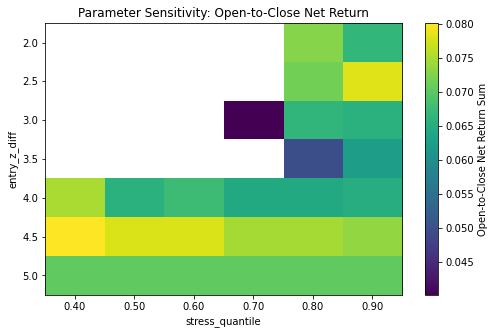

In [290]:
plt.figure(figsize=(8, 5))

plt.imshow(heat_table.to_numpy(), aspect="auto")

plt.colorbar(label="Open-to-Close Net Return Sum")

plt.xticks(
    ticks=np.arange(len(heat_table.columns)),
    labels=[f"{x:.2f}" for x in heat_table.columns],
)

plt.yticks(
    ticks=np.arange(len(heat_table.index)),
    labels=[f"{x:.1f}" for x in heat_table.index],
)

plt.xlabel("stress_quantile")
plt.ylabel("entry_z_diff")
plt.title("Parameter Sensitivity: Open-to-Close Net Return")
plt.show()

## Heatmap — 交易次數

In [291]:
trade_table = opt_df.pivot_table(
    index="entry_z_diff",
    columns="stress_quantile",
    values="trade_count",
    aggfunc="mean",
)

trade_table

stress_quantile,0.4,0.5,0.6,0.7,0.8,0.9
entry_z_diff,,,,,,
2.0,78.25,72.5,61.75,53.5,44.0,25.5
2.5,73.20,67.8,57.40,47.4,39.8,23.0
3.0,54.00,49.6,42.20,34.0,30.8,18.0
3.5,40.60,37.4,33.60,27.8,25.8,15.0
4.0,23.00,21.0,20.00,18.0,18.0,13.0
4.5,15.00,13.0,13.00,11.0,11.0,10.0
5.0,9.00,9.0,9.00,9.0,9.0,9.0


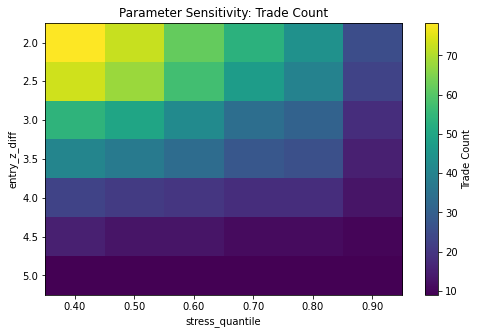

In [292]:
plt.figure(figsize=(8, 5))

plt.imshow(trade_table.to_numpy(), aspect="auto")

plt.colorbar(label="Trade Count")

plt.xticks(
    ticks=np.arange(len(trade_table.columns)),
    labels=[f"{x:.2f}" for x in trade_table.columns],
)

plt.yticks(
    ticks=np.arange(len(trade_table.index)),
    labels=[f"{x:.1f}" for x in trade_table.index],
)

plt.xlabel("stress_quantile")
plt.ylabel("entry_z_diff")
plt.title("Parameter Sensitivity: Trade Count")
plt.show()

## 選最佳參數並重跑

In [293]:
# ============================================================
# Best Parameter Backtest
# ============================================================

if filtered_opt.empty:
    raise ValueError("No valid parameter set found. Try relaxing filters.")

best = filtered_opt.sort_values("score", ascending=False).iloc[0]

best

run_id                     98.000000
stress_quantile             0.600000
entry_z_diff                4.500000
exit_z_diff                 1.000000
entry_z_diff_normal         5.000000
max_holding_days           10.000000
stop_loss                  -0.010000
vol_buffer_multiplier       0.250000
trade_count                13.000000
active_days                40.000000
close_total_return          0.096096
close_gross_return_sum      0.113373
close_cost_sum              0.020800
close_net_return_sum        0.092573
close_max_drawdown         -0.007844
close_turnover_sum         26.000000
close_exposure_ratio        0.070053
oc_total_return             0.080408
oc_gross_return_sum         0.098689
oc_cost_sum                 0.020800
oc_net_return_sum           0.077889
oc_max_drawdown            -0.009832
oc_turnover_sum            26.000000
oc_exposure_ratio           0.070053
delay2_total_return         0.032685
delay2_gross_return_sum     0.053157
delay2_cost_sum             0.020800
d

In [294]:
best_stress_quantile = float(best["stress_quantile"])
best_entry_z_diff = float(best["entry_z_diff"])
best_exit_z_diff = float(best["exit_z_diff"])

print("Best stress_quantile:", best_stress_quantile)
print("Best entry_z_diff:", best_entry_z_diff)
print("Best exit_z_diff:", best_exit_z_diff)

Best stress_quantile: 0.6
Best entry_z_diff: 4.5
Best exit_z_diff: 1.0


In [295]:
best_stress_threshold = market_abs_ret.rolling(stress_window).quantile(
    best_stress_quantile
)

best_stress_mode = market_abs_ret > best_stress_threshold

best_dynamic_min_edge = (
    2 * fee_rate
    + fixed_vol_buffer_multiplier * pair_vol_proxy
)

best_signals, best_trade_logs = generate_stateful_rv_signals_v21(
    relative_z=relative_z,
    relative_premium=relative_premium,
    stress_mode=best_stress_mode,
    dynamic_min_edge=best_dynamic_min_edge,
    entry_z_diff_stress=best_entry_z_diff,
    entry_z_diff_normal=fixed_entry_z_diff_normal,
    exit_z_diff=best_exit_z_diff,
    max_holding_days=fixed_max_holding_days,
    stop_loss=fixed_stop_loss,
    returns_for_pnl=returns,
)

print("Best trade count:", len(best_trade_logs))
print("Best active days:", (best_signals.abs().sum(axis=1) > 0).sum())

best_trade_logs

Best trade count: 13
Best active days: 40


,entry_date,exit_date,long_symbol,short_symbol,holding_days,entry_regime,entry_z_diff,exit_z_diff,entry_premium_diff,exit_premium_diff,trade_pnl_before_cost,exit_reason
0,2024-02-23,2024-02-27,00929,00878,2,normal,5.369613,0.638883,0.0082,0.0012,0.005775,mean_reversion
1,2024-03-05,2024-03-12,00929,00713,5,normal,5.074057,0.893665,0.0078,0.0052,0.010028,mean_reversion
2,2024-04-02,2024-04-17,00713,00929,9,normal,5.151710,0.549966,0.0068,0.0020,0.012595,mean_reversion
3,2024-05-16,2024-05-20,00919,00878,2,stress,5.353673,0.933769,0.0090,0.0033,0.002061,mean_reversion
4,2024-06-19,2024-06-25,00878,00929,4,stress,4.666812,-0.364459,0.0087,0.0021,0.006652,mean_reversion
5,2024-09-18,2024-09-23,00878,00919,3,normal,5.670175,0.691410,0.0068,0.0013,0.002214,mean_reversion
6,2024-12-03,2024-12-05,00929,00713,2,stress,4.906010,0.486040,0.0148,0.0050,0.005943,mean_reversion
7,2025-03-28,2025-04-02,00929,0056,3,stress,5.695733,-0.260201,0.0128,0.0070,0.004394,mean_reversion
8,2025-04-07,2025-04-09,00713,0056,2,stress,7.413744,-0.212017,0.0173,0.0015,0.035458,mean_reversion
9,2025-04-10,2025-04-11,00919,00713,1,stress,7.037289,0.189401,0.0288,0.0016,0.028293,mean_reversion


## 回測最佳參數

In [296]:
best_bt_close = backtest_signals(
    signals=best_signals,
    returns=returns,
    fee_rate=fee_rate,
    execution_lag=1,
)

best_bt_oc = backtest_signals(
    signals=best_signals,
    returns=open_to_close_returns,
    fee_rate=fee_rate,
    execution_lag=1,
)

best_bt_delay2 = backtest_signals(
    signals=best_signals,
    returns=returns,
    fee_rate=fee_rate,
    execution_lag=2,
)

best_compare = pd.DataFrame({
    "best_close_to_close": best_bt_close["metrics"],
    "best_open_to_close": best_bt_oc["metrics"],
    "best_delay2": best_bt_delay2["metrics"],
})

best_compare

,best_close_to_close,best_open_to_close,best_delay2
total_return,0.096096,0.080408,0.032685
gross_return_sum,0.113373,0.098689,0.053157
cost_sum,0.020800,0.020800,0.020800
net_return_sum,0.092573,0.077889,0.032357
max_drawdown,-0.007844,-0.009832,-0.006956
trade_days,40.000000,40.000000,40.000000
turnover_sum,26.000000,26.000000,26.000000
exposure_ratio,0.070053,0.070053,0.070053


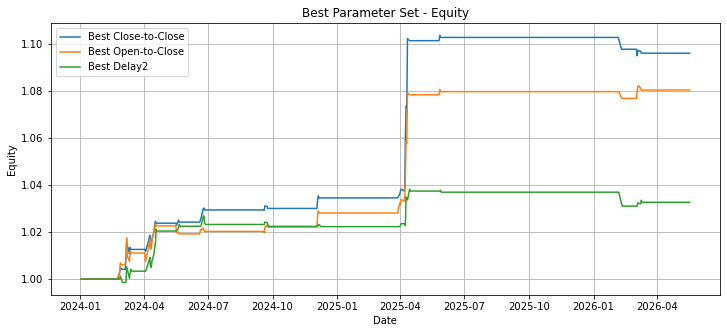

In [297]:
plt.figure(figsize=(12, 5))

plt.plot(
    best_bt_close["equity"].index.to_numpy(),
    best_bt_close["equity"].to_numpy(),
    label="Best Close-to-Close",
)

plt.plot(
    best_bt_oc["equity"].index.to_numpy(),
    best_bt_oc["equity"].to_numpy(),
    label="Best Open-to-Close",
)

plt.plot(
    best_bt_delay2["equity"].index.to_numpy(),
    best_bt_delay2["equity"].to_numpy(),
    label="Best Delay2",
)

plt.title("Best Parameter Set - Equity")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()
plt.grid(True)
plt.show()

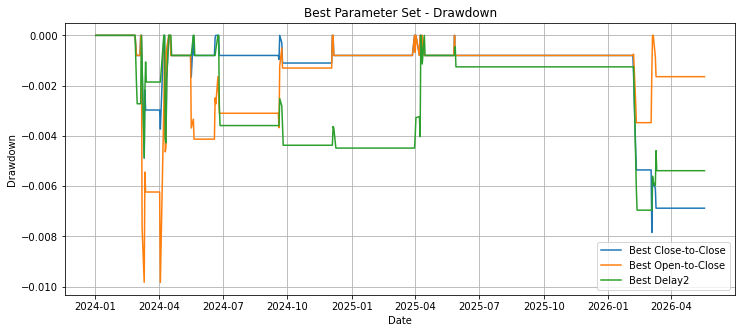

In [298]:
plt.figure(figsize=(12, 5))

plt.plot(
    best_bt_close["drawdown"].index.to_numpy(),
    best_bt_close["drawdown"].to_numpy(),
    label="Best Close-to-Close",
)

plt.plot(
    best_bt_oc["drawdown"].index.to_numpy(),
    best_bt_oc["drawdown"].to_numpy(),
    label="Best Open-to-Close",
)

plt.plot(
    best_bt_delay2["drawdown"].index.to_numpy(),
    best_bt_delay2["drawdown"].to_numpy(),
    label="Best Delay2",
)

plt.title("Best Parameter Set - Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

In [299]:
if not best_trade_logs.empty:
    display(best_trade_logs[
        [
            "entry_date",
            "exit_date",
            "long_symbol",
            "short_symbol",
            "holding_days",
            "entry_regime",
            "entry_z_diff",
            "exit_z_diff",
            "entry_premium_diff",
            "exit_premium_diff",
            "trade_pnl_before_cost",
            "exit_reason",
        ]
    ])

    print("Exit reason counts:")
    print(best_trade_logs["exit_reason"].value_counts())

    print("\nEntry regime counts:")
    print(best_trade_logs["entry_regime"].value_counts())

    print("\nLong counts:")
    print(best_trade_logs["long_symbol"].value_counts())

    print("\nShort counts:")
    print(best_trade_logs["short_symbol"].value_counts())

else:
    print("No trades generated under best parameters.")

,entry_date,exit_date,long_symbol,short_symbol,holding_days,entry_regime,entry_z_diff,exit_z_diff,entry_premium_diff,exit_premium_diff,trade_pnl_before_cost,exit_reason
0,2024-02-23,2024-02-27,00929,00878,2,normal,5.369613,0.638883,0.0082,0.0012,0.005775,mean_reversion
1,2024-03-05,2024-03-12,00929,00713,5,normal,5.074057,0.893665,0.0078,0.0052,0.010028,mean_reversion
2,2024-04-02,2024-04-17,00713,00929,9,normal,5.151710,0.549966,0.0068,0.0020,0.012595,mean_reversion
3,2024-05-16,2024-05-20,00919,00878,2,stress,5.353673,0.933769,0.0090,0.0033,0.002061,mean_reversion
4,2024-06-19,2024-06-25,00878,00929,4,stress,4.666812,-0.364459,0.0087,0.0021,0.006652,mean_reversion
5,2024-09-18,2024-09-23,00878,00919,3,normal,5.670175,0.691410,0.0068,0.0013,0.002214,mean_reversion
6,2024-12-03,2024-12-05,00929,00713,2,stress,4.906010,0.486040,0.0148,0.0050,0.005943,mean_reversion
7,2025-03-28,2025-04-02,00929,0056,3,stress,5.695733,-0.260201,0.0128,0.0070,0.004394,mean_reversion
8,2025-04-07,2025-04-09,00713,0056,2,stress,7.413744,-0.212017,0.0173,0.0015,0.035458,mean_reversion
9,2025-04-10,2025-04-11,00919,00713,1,stress,7.037289,0.189401,0.0288,0.0016,0.028293,mean_reversion


Exit reason counts:
exit_reason
mean_reversion    13
Name: count, dtype: int64

Entry regime counts:
entry_regime
stress    8
normal    5
Name: count, dtype: int64

Long counts:
long_symbol
00929    4
00878    4
00919    3
00713    2
Name: count, dtype: int64

Short counts:
short_symbol
00878    3
00713    3
00919    3
00929    2
0056     2
Name: count, dtype: int64


In [300]:
# ============================================================
# Yearly Performance Check
# Use open-to-close as the main evaluation version
# ============================================================

best_strategy_ret = best_bt_oc["strategy_ret"].copy()

yearly_perf = (
    best_strategy_ret
    .groupby(best_strategy_ret.index.year)
    .agg(["sum", "mean", "std", "count"])
)

yearly_perf["annualized_vol"] = yearly_perf["std"] * np.sqrt(252)

yearly_perf["sharpe_like"] = (
    yearly_perf["mean"] * 252
    / yearly_perf["annualized_vol"].replace(0, np.nan)
)

yearly_perf

,sum,mean,std,count,annualized_vol,sharpe_like
date,,,,,,
2024,0.027912,0.000115,0.001187,242,0.018836,1.543100
2025,0.049350,0.000203,0.001747,243,0.027731,1.845499
2026,0.000627,0.000007,0.000455,86,0.007223,0.254167
